In [1]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import functions
import pybamm
import numpy as np
from tqdm import trange
import optuna

/home/dlu-apa/.pyenv/versions/3.11.5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import jax
print("All devices:", jax.devices())
print("Default backend:", jax.default_backend())


All devices: [CudaDevice(id=0)]
Default backend: gpu


In [3]:
from FNO import *

In [4]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [5]:
spm = pybamm.lithium_ion.SPM()
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]

def get_targets(I_samples, soc=0.5):
    set_targets = []
    set_c0 = []

    I_pruned = []
    
    for id, I_func in enumerate(I_samples):
        # Update parameter
        params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* I_func, pybamm.t)
        
        # Re-create the simulation with updated parameters
        sim = pybamm.Simulation(spm, parameter_values=params_bat)
        
        sol = sim.solve(initial_soc=soc, t_eval=t)
        c0 = sol["Negative particle concentration"].entries[:,0,0]
        cn_target = sol["Negative particle concentration"].entries[:,0,:]

        if cn_target.shape[-1] != num_samples_I:
            continue
        else:
            I_pruned.append(I_func)
        
        set_targets.append(cn_target)
        set_c0.append(c0)

    
    return set_targets, set_c0, I_pruned


# def generate_data(key, num):
#     keys = jax.random.split(key, num)
#     func_I = []
#     for k in keys:
#         # Generate a random current function
#         I_func = functions.GaussianRFCurrent(k, C, t_max)
#         func_I.append(I_func(t))
#     return func_I

def generate_data(key, num):
    keys = jax.random.split(key, num)
    train_I = []
    for k in keys:
        # Sample a random amplitude value for the triangle current
        value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
        I_func = functions.TriangleCurrent(value * C)
        train_I.append(I_func(t))
    return train_I

# def generate_data(key, num_samples):
#     keys = jax.random.split(key, num_samples)
#     set_I = []
#     for k in keys:
#         # Generate a random constant current value between -1C and 1C
#         rand_value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
        
#         # Create a constant current function with that value
#         I_func = functions.ConstantCurrent(rand_value*C)
#         # Evaluate at times t and append
#         set_I.append(I_func(t))
#     return set_I

In [6]:
# train_I = generate_data(key_train, num_train)
# test_I = generate_data(key_test, num_test)
# train_cn, train_c0, train_I = get_targets(train_I)
# test_cn, test_c0, test_I = get_targets(test_I)

# train_I = jnp.array(train_I)
# test_I = jnp.array(test_I)
# train_cn = jnp.array(train_cn)
# test_cn = jnp.array(test_cn)
# train_c0 = jnp.array(train_c0)
# test_c0 = jnp.array(test_c0)

In [7]:
# plt.plot(t,train_cn[2,-1,:])

In [8]:
# seen = set()
# duplicates_found = False

# for i in range(num_train):
#     # Extract the i-th dataset from the batch
#     dataset = train_I[i]

#     # Convert to a NumPy array and then to bytes for hashing
#     dataset_hash = hash(np.array(dataset).tobytes())

#     if dataset_hash in seen:
#         print(f"Duplicate dataset found at index {i}.")
#         duplicates_found = True
#         break
#     else:
#         seen.add(dataset_hash)

# if not duplicates_found:
#     print("No duplicates found among the 2000 samples in the batch.")

In [9]:
filename = "GRF"
path = "data/spm/"
train_data = np.load(path + "train/" + filename + ".npz")
test_data = np.load(path + "test/" + filename + ".npz")

In [10]:
# import matplotlib.pyplot as plt

# # Suppose train_data["current"] is a numpy array of shape (14, 75),
# # and we have some known battery capacity in ampere-hours, e.g. C = 5.0
# data = train_data["current"]

# # Create a figure with one Axes, then a twin Axes for second scale
# fig, ax1 = plt.subplots(figsize=(8, 5))

# # Plot the currents on ax1
# for i in range(data.shape[0]):
#     ax1.plot(data[i, :], label=f"Series {i}")

# ax1.set_xlabel("Index (time steps)")
# ax1.set_ylabel("Current [A]", color="blue")
# ax1.tick_params(axis='y', labelcolor="blue")

# # Create second y‐axis for the C‐rate
# ax2 = ax1.twinx()
# for i in range(data.shape[0]):
#     # Convert current [A] into C‐rate by dividing by capacity [Ah]
#     # (If your capacity is in different units, adjust accordingly)
#     c_rate = data[i, :] / C
#     ax2.plot(c_rate, linestyle="--", alpha=0.7)

# ax2.set_ylabel("C-rate", color="red")
# ax2.tick_params(axis='y', labelcolor="red")

# plt.title("Currents (left axis) and C-rates (right axis)")
# plt.show()


In [11]:
# data = train_data["target_concentration_anode"]

# plt.figure(figsize=(8, 5))

# for i in range(data.shape[0]):  # i goes from 0 to 13
#     plt.plot(data[i,-1, :], label=f"Series {i}")

# plt.xlabel("Index (time steps)")
# plt.ylabel("Concentration Value Normalised")
# #plt.title("All 14 Current Traces in One Plot")
# #plt.legend()
# plt.show()

In [12]:
# data = train_data["initial_concentration_anode"]

# plt.figure(figsize=(8, 5))

# for i in range(data.shape[0]):  # i goes from 0 to 13
#     plt.plot(data[i,:], label=f"Series {i}")

# plt.xlabel("Index (time steps)")
# plt.ylabel("Concentration Value Normalised")
# #plt.title("All 14 Current Traces in One Plot")
# #plt.legend()
# plt.show()

In [13]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn = jnp.array(train_data["target_concentration_anode"])
test_cn = jnp.array(test_data["target_concentration_anode"])

train_c0 = jnp.array(train_data["initial_concentration_anode"])
test_c0 = jnp.array(test_data["initial_concentration_anode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU




In [14]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
output_channels = 1

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar

# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)

# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
out = model.apply(params, input_tensor)
print("Output shape:", out.shape)  # should be (1,24,85,1)


Output shape: (1, 24, 85, 1)


In [15]:
def preprocess_data(train_I, train_c0, train_cn):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)


    # Prepare arrays for output
    X = jnp.zeros((num_samples, H, W, 4))
    Y = jnp.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)

    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = jnp.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = jnp.tile(c0_padded[:, :, None], (1, 1, W))

    # R,T are the same for all samples, just expand
    R_3D = jnp.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = jnp.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)

    # Stack channels: (num_samples,24,85,4)
    X = jnp.stack([I_2D, c0_2D, R_3D, T_3D], axis=-1)

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = jnp.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [16]:
def data_loader(X: np.ndarray, Y: np.ndarray, batch_size: int, shuffle: bool = True):
    """
    A simple data loader that yields batches of preprocessed FNO data.
    
    Parameters
    ----------
    X : jnp.ndarray
        Preprocessed input data of shape (num_samples, 24,85,4).
    Y : jnp.ndarray
        Preprocessed target data of shape (num_samples, 24,85,1).
    batch_size : int
        Number of samples per batch.
    shuffle : bool
        Whether to shuffle the dataset before yielding batches.

    Yields
    ------
    (X_batch, Y_batch) : tuple of jnp.ndarray
        X_batch : (batch_size, 24,85,4)
        Y_batch : (batch_size, 24,85,1)
    """
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
    for start_idx in range(0, num_samples, batch_size):
        batch_indices = indices[start_idx:start_idx+batch_size]
        yield X[batch_indices], Y[batch_indices]



In [17]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [18]:
# Setup optimizer (Adam)
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)

In [19]:
def loss_fn(params, X_batch, Y_batch):
    preds = model.apply(params, X_batch)  # (batch_size, H, W, 1)
    # Compute mean squared error over all spatial points and batch
    return relative_l2_loss(preds.flatten(), Y_batch.flatten())

In [20]:
@jax.jit
def train_step(params, opt_state, X_batch, Y_batch):
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch, Y_batch)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [21]:
# train_I = np.repeat(train_I,11,axis=0)
# test_I = np.repeat(test_I,11,axis=0)

In [22]:
X_train, Y_train = preprocess_data(train_I, train_c0, train_cn)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn)

In [23]:
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)

X_train shape: (22000, 24, 85, 4) dtype: float32
Y_train shape: (22000, 24, 85, 1) dtype: float32


In [24]:
X_train.device

CudaDevice(id=0)

In [25]:
Y_train[0,2:22,5:80,:].squeeze()

Array([[ 0.0263473 ,  0.02626039,  0.02490546, ..., -0.5770178 ,
        -0.58765084, -0.5968159 ],
       [ 0.0263473 ,  0.02625195,  0.02486876, ..., -0.5772198 ,
        -0.5878277 , -0.5969655 ],
       [ 0.0263473 ,  0.02623414,  0.02479491, ..., -0.57762307,
        -0.5881805 , -0.59726393],
       ...,
       [ 0.0263473 ,  0.02098805,  0.01899059, ..., -0.6048251 ,
        -0.61135554, -0.6161129 ],
       [ 0.0263473 ,  0.02000495,  0.01845703, ..., -0.60767215,
        -0.6136872 , -0.6178932 ],
       [ 0.0263473 ,  0.0189588 ,  0.01797273, ..., -0.61057746,
        -0.61604106, -0.6196575 ]], dtype=float32)

In [26]:
# X_train = X_train[:22000]
# Y_train = Y_train[:22000]

# X_test = X_test[:2200]
# Y_test = Y_test[:2200]

In [27]:
X_train.shape

(22000, 24, 85, 4)

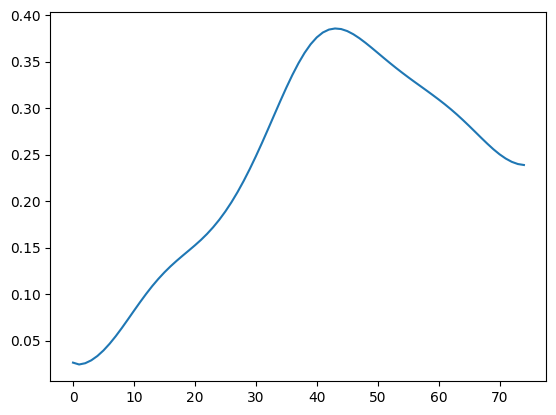

In [28]:
plt.plot(train_cn[20,-1,:])

In [29]:
num_epochs = 100
pbar = trange(num_epochs, desc="Training")

batch_size = 32

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, X_batch, Y_batch)
        total_train_loss += loss_value
        count += 1
    

    total_test_loss = 0.0
    count2 = 0

    for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
        test_pred = model.apply(params, X_batch)
        loss_value = loss_fn(params, X_batch, Y_batch)
        total_test_loss += loss_value
        count2 += 1


    train_losses.append(total_train_loss)
    test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)


Training:   0%|          | 0/100 [00:10<?, ?it/s]


KeyboardInterrupt: 

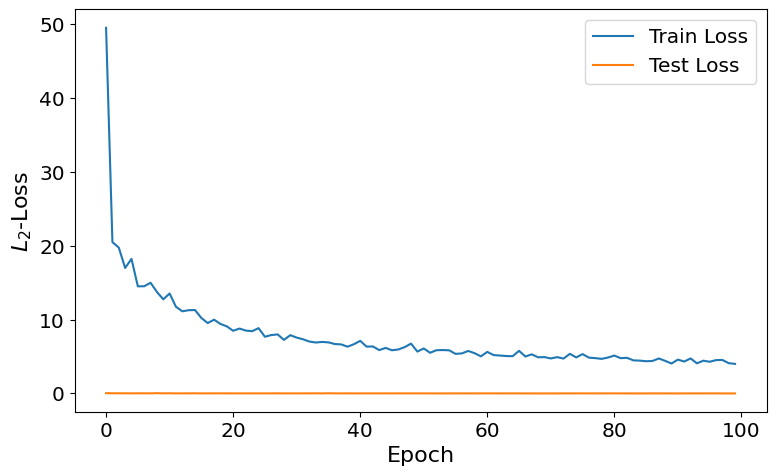

In [30]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [2]:
train_idx = np.random.randint(2, 22000)
test_idx = np.random.randint(2, 2200)

NameError: name 'np' is not defined

In [32]:
X_train[3][None,...].shape

(1, 24, 85, 4)

In [33]:
c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...])

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...])

H_orig = 20
W_orig = 75
padding_r = 2
padding_t = 5

# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_pred_reshaped = c_train_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped = c_train_true  # already (20,75)

c_test_pred_reshaped = c_test_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped = c_test_true   # already (20,75)


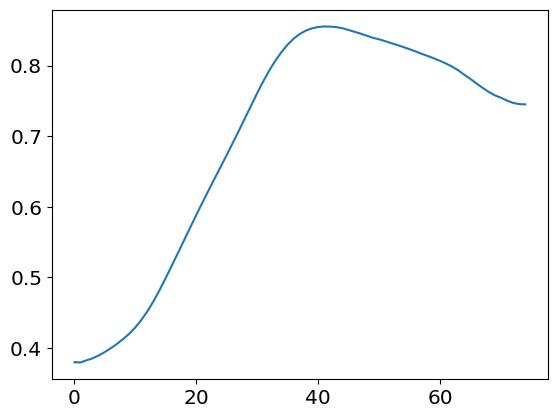

In [ ]:
plt.plot(c_train_pred_reshaped[-1,:])

In [35]:
c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

In [36]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max


In [1]:
# Compute error lines
train_error_line = jnp.mean(jnp.abs(c_train_pred_scaled - c_train_true_scaled), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_scaled - c_test_true_scaled), axis=0)      # shape (75,)


NameError: name 'jnp' is not defined

In [38]:
c_train_pred_scaled[:,:].shape
#c_train_true_scaled[20,:]

(20, 75)

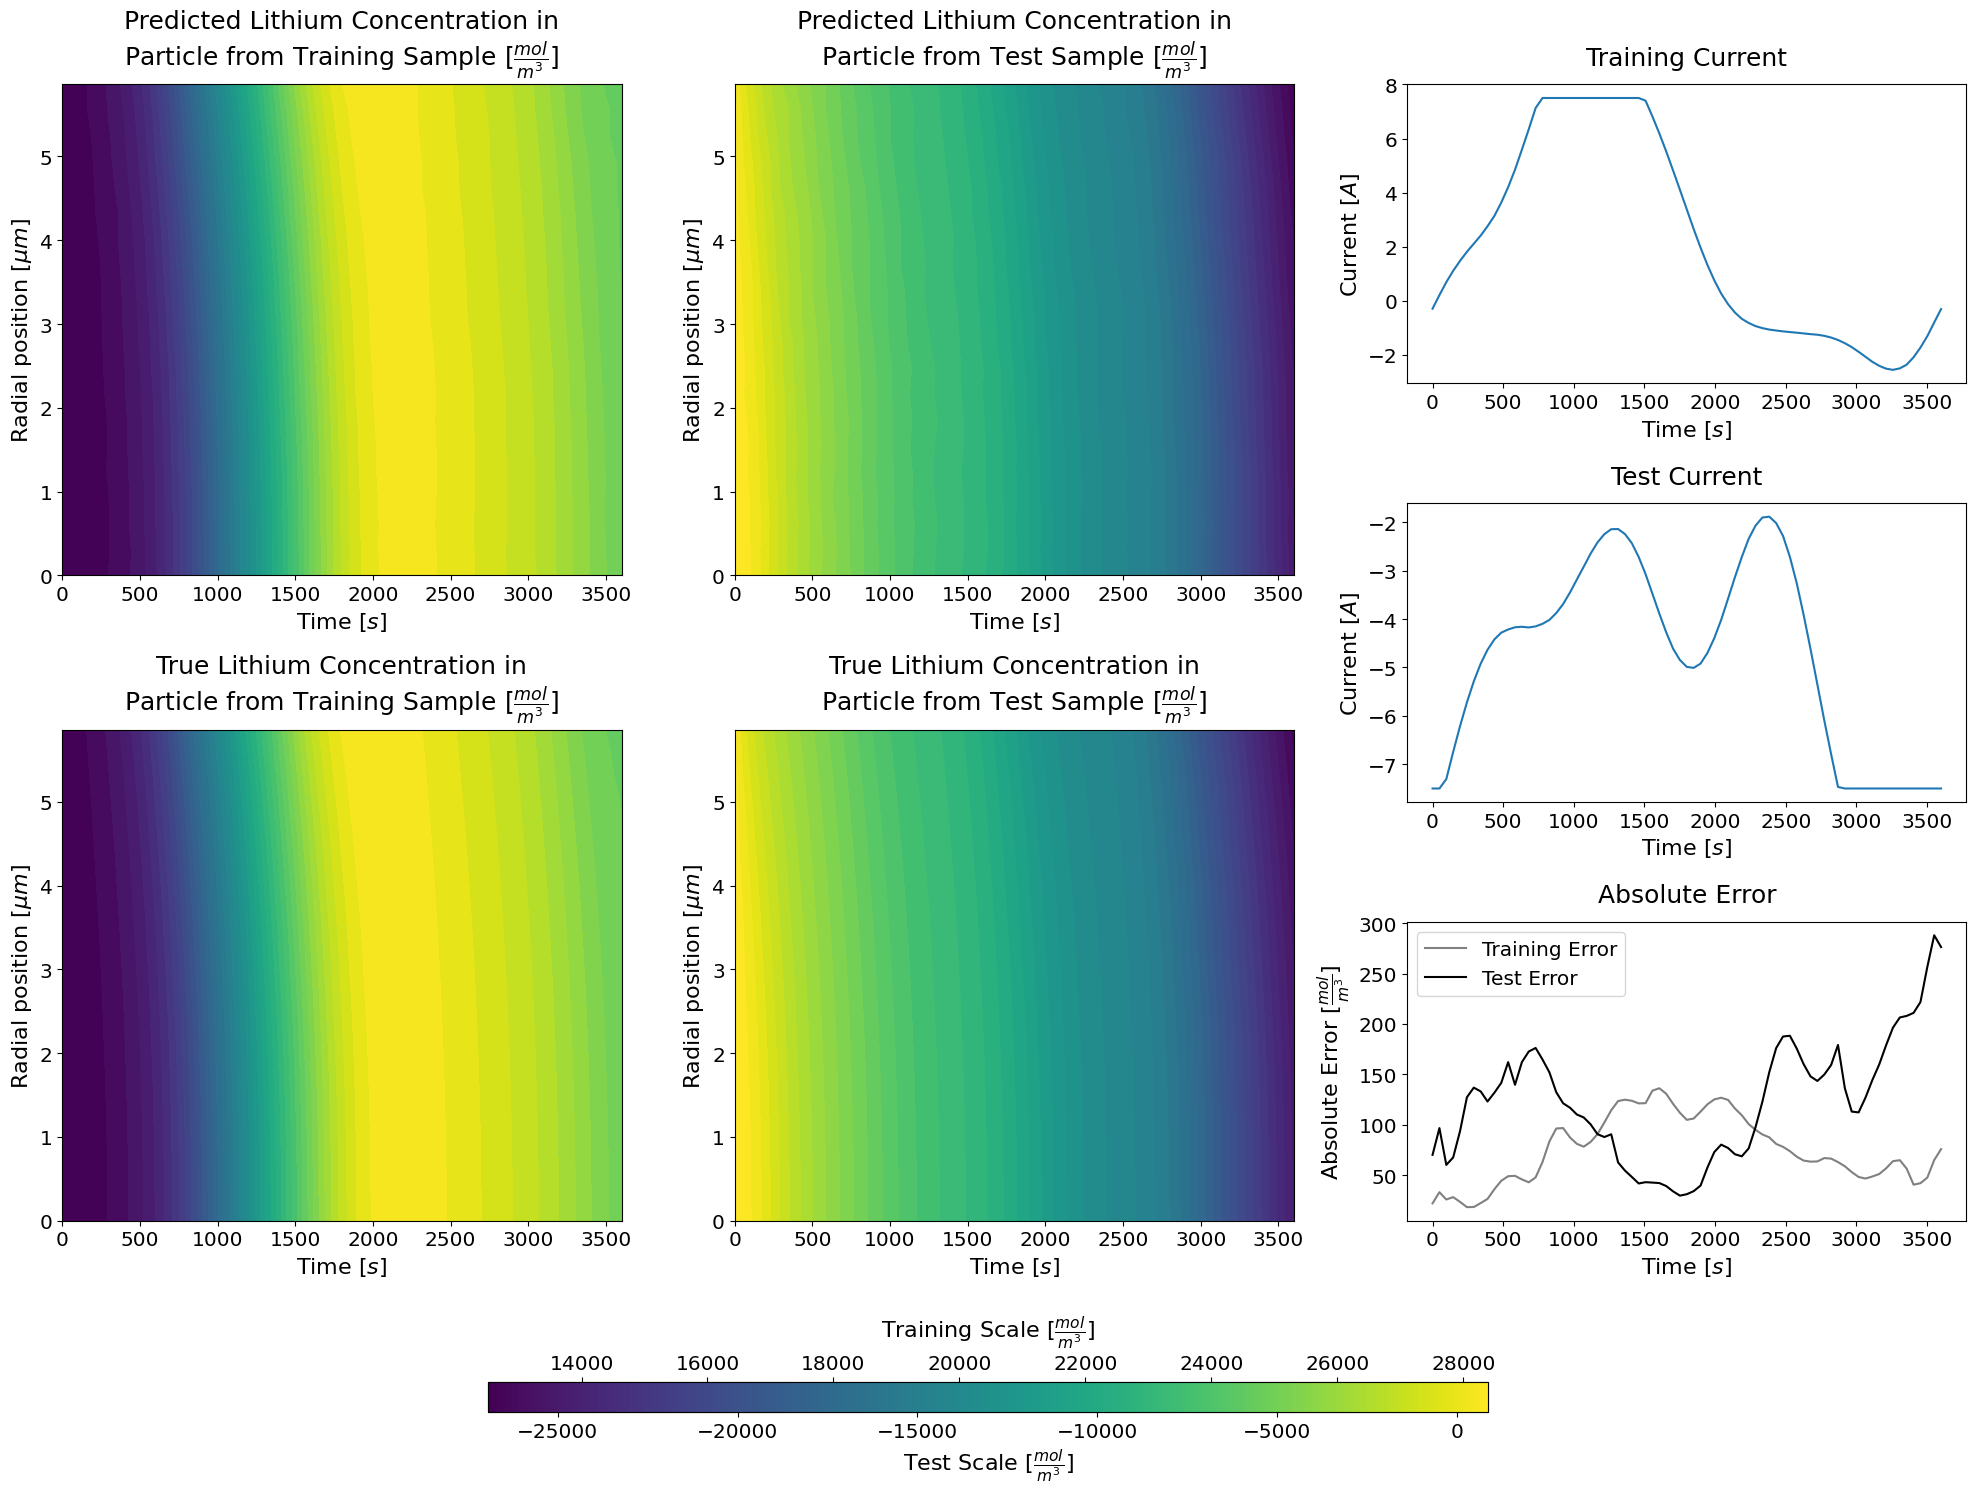

In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled.ravel(),
    c_train_true_scaled.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled.ravel(),
    c_test_true_scaled.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [ ]:
train_c0[train_idx]

Array([0.38005322, 0.38005322, 0.38005322, 0.38005322, 0.38005322,
       0.38005322, 0.38005322, 0.38005322, 0.38005322, 0.38005322,
       0.38005322, 0.38005322, 0.38005322, 0.38005322, 0.38005322,
       0.38005322, 0.38005322, 0.38005322, 0.38005322, 0.38005322],      dtype=float32)

In [ ]:
test_c0[test_idx]

Array([0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473, 0.0263473,
       0.0263473, 0.0263473], dtype=float32)

In [42]:
import os
import flax.serialization
from datetime import datetime

In [43]:
# def save_model_params(params, directory="./trained_models", prefix = "anode"):
#     """Serialize and save model params with a timestamped filename."""
#     os.makedirs(directory, exist_ok=True)
#     # Create a unique timestamp string, e.g. "2025-03-06_14-20-59"
#     timestamp_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
#     # Construct filename, e.g. "./checkpoints/model_params_2025-03-06_14-20-59.msgpack"
#     filename = os.path.join(directory, f"{prefix}_{timestamp_str}.msgpack")

#     # Convert params PyTree to a bytes object
#     param_bytes = flax.serialization.to_bytes(params)

#     # Write to disk
#     with open(filename, "wb") as f:
#         f.write(param_bytes)

#     print(f"Saved model parameters to {filename}")
#     return filename

In [30]:
filename = functions.save_model_params(params, family = filename)

Saved model parameters to ./trained_model/anode_GRF_2025-03-06_20-23-51.msgpack


In [ ]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn = jnp.array(train_data["target_concentration_cathode"])
test_cn = jnp.array(test_data["target_concentration_cathode"])

train_c0 = jnp.array(train_data["initial_concentration_cathode"])
test_c0 = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU


X_train, Y_train = preprocess_data(train_I, train_c0, train_cn)
X_test, Y_test = preprocess_data(test_I, test_c0, test_cn)

In [ ]:
# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
out = model.apply(params, input_tensor)
print("Output shape:", out.shape)  # should be (1,24,85,1)

In [ ]:
num_epochs = 100
pbar = trange(num_epochs, desc="Training")

batch_size = 32

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, Y_batch in data_loader(X_train, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, X_batch, Y_batch)
        total_train_loss += loss_value
        count += 1
    

    total_test_loss = 0.0
    count2 = 0

    for X_batch, Y_batch in data_loader(X_test, Y_test, 200):
        test_pred = model.apply(params, X_batch)
        loss_value = loss_fn(params, X_batch, Y_batch)
        total_test_loss += loss_value
        count2 += 1


    train_losses.append(total_train_loss)
    test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

In [ ]:
filename = functions.save_model_params(params, prefix = "cathode", family = filename)

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

# After training, plot results
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('$L_2$-Loss')
#plt.title('Training vs Test Loss (Bias-Variance)')
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig("DON/Loss_DON" + ".svg", format='svg', transparent=True)
plt.show()

In [ ]:
c_train_true = train_cn[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...])

c_test_true = test_cn[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...])

H_orig = 20
W_orig = 75
padding_r = 2
padding_t = 5

# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_pred_reshaped = c_train_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_train_true_reshaped = c_train_true  # already (20,75)

c_test_pred_reshaped = c_test_pred[0, padding_r:padding_r+H_orig, padding_t:padding_t+W_orig, 0]
c_test_true_reshaped = c_test_true   # already (20,75)

In [ ]:
c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

In [ ]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max

In [ ]:
# Compute error lines
train_error_line = jnp.mean(jnp.abs(c_train_pred_scaled - c_train_true_scaled), axis=0)  # shape (75,)
test_error_line = jnp.mean(jnp.abs(c_test_pred_scaled - c_test_true_scaled), axis=0)      # shape (75,)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled.ravel(),
    c_train_true_scaled.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled.ravel(),
    c_test_true_scaled.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()